# Notebook 02: Hypothesis Testing & Preprocessing
## Credit Risk & Loan Amount Prediction | LendingClub

This notebook covers two phases:

**Phase 1 — Hypothesis Testing**  
We statistically validate the visual patterns observed in notebook 01.
Visual EDA tells us what *appears* to be true. Hypothesis testing tells us
what is *statistically* true with measurable confidence.

**Phase 2 — Preprocessing**  
We clean the dataset systematically — dropping sparse columns, fixing outliers,
encoding categorical variables, and preparing a clean feature matrix ready
for feature engineering in notebook 03.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the filtered parquet file saved at the end of notebook 01
# Parquet preserves all data types exactly as saved — no re-parsing needed
df = pd.read_parquet("../data/loans_filtered.parquet")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 915,420 rows x 152 columns


## Phase 1: Hypothesis Testing

We run three statistical tests to validate key patterns observed in EDA.
Each test is chosen based on the data types involved and the nature of
the relationship being tested.

### Significance Level
We use alpha = 0.05 throughout. A p-value below 0.05 means we reject
the null hypothesis and conclude the observed relationship is statistically
significant.

In [3]:
# Test 1: Independent samples t-test
# Question: Do defaulters have significantly different annual income
# compared to non-defaulters?
#
# H0: Mean annual income is equal for defaulters and non-defaulters
# H1: Mean annual income differs significantly between the two groups
#
# We use the t-test here because we are comparing a continuous variable
# (annual_inc) across two independent groups (default = 0 and default = 1)

defaulters = df[df["default"] == 1]["annual_inc"].dropna()
non_defaulters = df[df["default"] == 0]["annual_inc"].dropna()

t_stat, p_value = stats.ttest_ind(defaulters, non_defaulters, equal_var=False)

print("Test 1: Independent Samples T-Test")
print("Question: Does annual income differ between defaulters and non-defaulters?")
print()
print(f"Mean income — Defaulters    : ${defaulters.mean():,.2f}")
print(f"Mean income — Non-defaulters: ${non_defaulters.mean():,.2f}")
print()
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 — The difference in income is statistically significant.")
else:
    print("Result: Fail to reject H0 — No significant difference in income found.")

Test 1: Independent Samples T-Test
Question: Does annual income differ between defaulters and non-defaulters?

Mean income — Defaulters    : $72,277.09
Mean income — Non-defaulters: $79,503.88

T-statistic : -39.4022
P-value     : 0.000000

Result: Reject H0 — The difference in income is statistically significant.


In [4]:
# Test 2: Chi-Square Test of Independence
# Question: Is loan grade associated with default outcome?
#
# H0: Loan grade and default status are independent (no association)
# H1: Loan grade and default status are associated
#
# We use chi-square here because both variables are categorical —
# grade (A through G) and default (0 or 1). The t-test only works
# for continuous variables, so chi-square is the correct choice here.

contingency_table = pd.crosstab(df["grade"], df["default"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Test 2: Chi-Square Test of Independence")
print("Question: Is loan grade associated with default outcome?")
print()
print("Observed Counts:")
print(contingency_table)
print()
print(f"Chi-square statistic : {chi2_stat:,.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 — Loan grade and default are significantly associated.")
else:
    print("Result: Fail to reject H0 — No significant association found.")

Test 2: Chi-Square Test of Independence
Question: Is loan grade associated with default outcome?

Observed Counts:
default       0      1
grade                 
A        150518  11358
B        220712  42205
C        197840  70701
D         85559  47530
E         35062  27349
F          9650  10543
G          2850   3543

Chi-square statistic : 72,453.56
Degrees of freedom   : 6
P-value              : 0.000000

Result: Reject H0 — Loan grade and default are significantly associated.


In [5]:
# Test 3: One-Way ANOVA
# Question: Does mean interest rate differ significantly across loan purposes?
#
# H0: Mean interest rate is equal across all loan purposes
# H1: At least one loan purpose has a significantly different mean interest rate
#
# We use ANOVA here because we are comparing a continuous variable (int_rate)
# across more than two groups (14 loan purposes). The t-test only handles
# two groups — ANOVA generalizes this to multiple groups simultaneously.

purpose_groups = [
    group["int_rate"].dropna().values
    for name, group in df.groupby("purpose")
]

f_stat, p_value = stats.f_oneway(*purpose_groups)

print("Test 3: One-Way ANOVA")
print("Question: Does interest rate differ significantly across loan purposes?")
print()
print("Mean interest rate by purpose:")
print()
print(df.groupby("purpose")["int_rate"].mean().sort_values(ascending=False).round(3))
print()
print(f"F-statistic : {f_stat:,.2f}")
print(f"P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 — Interest rate differs significantly across loan purposes.")
else:
    print("Result: Fail to reject H0 — No significant difference found.")

Test 3: One-Way ANOVA
Question: Does interest rate differ significantly across loan purposes?

Mean interest rate by purpose:

purpose
wedding              16.900
small_business       15.942
house                15.537
renewable_energy     15.258
moving               14.805
other                14.211
medical              13.571
debt_consolidation   13.459
vacation             13.252
major_purchase       12.807
home_improvement     12.566
car                  12.139
educational          11.530
credit_card          11.471
Name: int_rate, dtype: float64

F-statistic : 2,650.28
P-value     : 0.000000

Result: Reject H0 — Interest rate differs significantly across loan purposes.


## Hypothesis Testing Summary

All three tests produced p-values effectively equal to zero, far below our
alpha threshold of 0.05. We reject all three null hypotheses.

| Test | Question | Result | Implication |
|---|---|---|---|
| T-Test | Does income differ by default? | Significant | Income is a valid predictive feature |
| Chi-Square | Is grade associated with default? | Significant | Grade is a strong categorical predictor |
| ANOVA | Does interest rate differ by purpose? | Significant | Purpose influences pricing and risk |

These findings statistically confirm what we observed visually in notebook 01.
All three features — annual_inc, grade, and purpose — are justified for inclusion
in our models on both visual and statistical grounds.

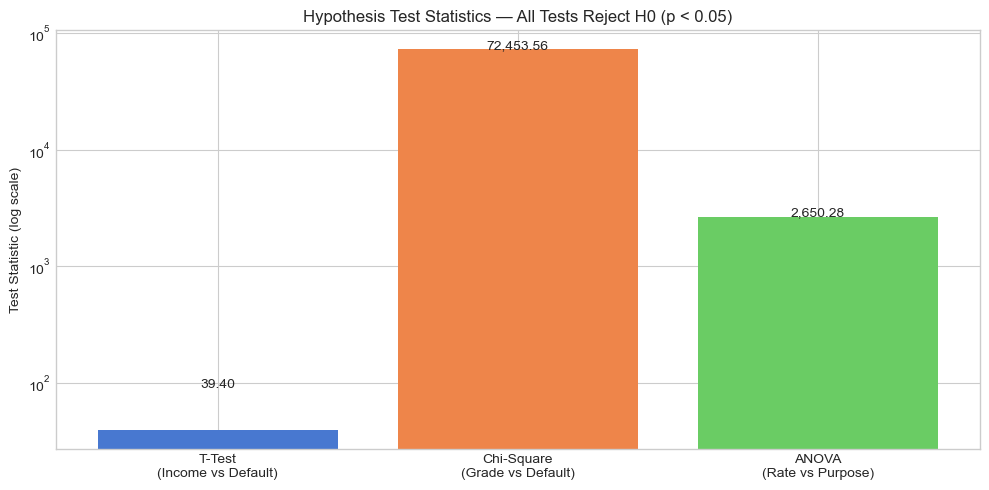

In [6]:
# Summary visualization of all three hypothesis test results
# We plot the test statistic magnitude for each test to show
# how decisively each null hypothesis was rejected

tests = ["T-Test\n(Income vs Default)", 
         "Chi-Square\n(Grade vs Default)", 
         "ANOVA\n(Rate vs Purpose)"]

# We use log scale because the statistics differ vastly in magnitude
statistics = [39.40, 72453.56, 2650.28]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(tests, statistics,
              color=sns.color_palette("muted")[:3])

for bar, val in zip(bars, statistics):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"{val:,.2f}", ha="center", fontsize=10)

ax.set_yscale("log")
ax.set_ylabel("Test Statistic (log scale)")
ax.set_title("Hypothesis Test Statistics — All Tests Reject H0 (p < 0.05)")

plt.tight_layout()
plt.show()

## Phase 2: Preprocessing

We systematically clean the dataset in the following order:

1. Drop columns exceeding the 40% missing threshold
2. Drop columns that cause data leakage
3. Fix outliers in numerical features
4. Handle remaining missing values
5. Encode categorical variables
6. Final feature selection and save

Each step is documented with the reasoning behind the decision.

### Step 1: Drop High-Missing Columns

Any column missing more than 40% of its values is dropped. As established
in notebook 01, these are event-driven administrative fields (hardship plans,
settlement records, joint application fields) that are absent for the vast
majority of borrowers and cannot be meaningfully imputed.

In [7]:
# Identify columns exceeding the 40% missing threshold
missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop_missing = missing_pct[missing_pct > 40].index.tolist()

print(f"Columns to drop due to >40% missing values: {len(cols_to_drop_missing)}")
print()
print(cols_to_drop_missing)

df.drop(columns=cols_to_drop_missing, inplace=True)

print()
print(f"Shape after dropping high-missing columns: {df.shape[0]:,} rows x {df.shape[1]} columns")

Columns to drop due to >40% missing values: 46

['member_id', 'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'il_util', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_a

### Step 2: Remove Data Leakage Columns

Data leakage occurs when features available at prediction time contain
information that would not actually be known at the moment of making a
prediction in the real world.

In a loan default prediction model, we are making predictions AT THE TIME
OF LOAN APPLICATION. Any column that is only populated AFTER the loan is
issued — such as payment history, recovery amounts, or charged-off figures —
must be removed. Including them would make the model artificially accurate
during training but completely useless in production, because these values
would not exist for a new applicant.

This is one of the most common and costly mistakes in real-world ML projects.

In [8]:
# These columns are all populated post-loan-issuance
# They record what happened during repayment, not what was known at application
# Including any of these would constitute data leakage

leakage_cols = [
    "out_prncp",           # remaining principal — only exists after payments begin
    "out_prncp_inv",       # remaining principal (investor portion)
    "total_pymnt",         # total amount paid to date
    "total_pymnt_inv",     # total paid to investors
    "total_rec_prncp",     # principal received to date
    "total_rec_int",       # interest received to date
    "total_rec_late_fee",  # late fees received
    "recoveries",          # post-default recovery amount
    "collection_recovery_fee",  # fee on recovery
    "last_pymnt_d",        # date of last payment
    "last_pymnt_amnt",     # amount of last payment
    "next_pymnt_d",        # scheduled next payment date
    "last_credit_pull_d",  # last time LC pulled credit
    "last_fico_range_high",# FICO at last pull — post-issuance
    "last_fico_range_low", # FICO at last pull — post-issuance
    "loan_status",         # the raw source of our target — must be removed
    "default"              # we will add this back after — temporary removal
]

# Keep only columns that exist in the current dataframe
leakage_cols = [col for col in leakage_cols if col in df.columns]

# Store the target variable before dropping
target_default = df["default"].copy()
target_loan_amnt = df["loan_amnt"].copy()

df.drop(columns=leakage_cols, inplace=True)

# Add targets back as clean separate columns
df["default"] = target_default
df["loan_amnt"] = target_loan_amnt

print(f"Leakage columns removed: {len(leakage_cols)}")
print(f"Shape after leakage removal: {df.shape[0]:,} rows x {df.shape[1]} columns")

Leakage columns removed: 16
Shape after leakage removal: 915,420 rows x 91 columns


### Step 3: Fix Outliers in Numerical Features

We identified three columns with physically impossible or extreme values
in notebook 01:

- `annual_inc`: max of $10.99M — extreme right skew from a handful of values
- `dti`: max of 999 and min of -1 — impossible values, valid range is 0 to 100
- `revol_util`: max of 193% — values above 100% are suspicious

We use the 99th percentile cap for `annual_inc` and `revol_util` rather than
dropping rows, because these are likely legitimate borrowers with extreme but
real values. Hard limits are applied to `dti` since negative and >100 values
are financially meaningless.

Capping at the 99th percentile rather than dropping preserves sample size
while eliminating the distorting effect of extreme values on model training.

In [9]:
# Fix annual_inc — cap at 99th percentile
inc_cap = df["annual_inc"].quantile(0.99)
df["annual_inc"] = df["annual_inc"].clip(upper=inc_cap)

# Fix dti — hard limits: valid range is 0 to 100
df = df[(df["dti"] >= 0) & (df["dti"] <= 100)]

# Fix revol_util — cap at 100 since utilization above 100% is not meaningful
df["revol_util"] = df["revol_util"].clip(upper=100)

print(f"Shape after outlier fixing: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Revised statistics after capping:")
print()
print(df[["annual_inc", "dti", "revol_util"]].describe())

Shape after outlier fixing: 914,430 rows x 91 columns

Revised statistics after capping:

       annual_inc        dti  revol_util
count  914430.000 914430.000  913837.000
mean    76097.028     18.720      49.652
std     43893.395      9.068      24.610
min       430.000      0.000       0.000
25%     47000.000     12.070      31.000
50%     65000.000     18.070      49.400
75%     93000.000     24.810      68.400
max    266000.000    100.000     100.000


### Step 4: Handle Remaining Missing Values

With high-missing columns already dropped, the remaining missing values
are in columns we intend to keep. We apply different strategies based
on the data type and distribution of each column:

- Numerical columns: impute with median — robust to skew, unaffected by outliers
- Categorical columns: impute with mode — most frequent category is the safest
  default assumption for sparse categorical fields

In [11]:
# Check remaining missing values after previous cleaning steps
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print(f"Columns still containing missing values: {len(remaining_missing)}")
print()
print(remaining_missing)

Columns still containing missing values: 28

all_util                 357950
open_acc_6m              357895
total_cu_tl              357895
inq_last_12m             357895
total_bal_il             357894
open_rv_12m              357894
max_bal_bc               357894
inq_fi                   357894
open_rv_24m              357894
open_il_12m              357894
open_act_il              357894
open_il_24m              357894
mths_since_recent_inq     87824
emp_title                 60156
emp_length                59169
num_tl_120dpd_2m          43310
mo_sin_old_il_acct        25755
title                     16917
bc_util                   10833
percent_bc_gt_75          10596
bc_open_to_buy            10295
mths_since_recent_bc       9745
revol_util                  593
avg_cur_bal                  11
inq_last_6mths                1
zip_code                      1
num_rev_accts                 1
pct_tl_nvr_dlq                1
dtype: int64


In [12]:
# The top 12 columns are all missing ~39% of values and are missing together
# as a block — they relate to installment account details unavailable for
# a large portion of borrowers. Imputing 39% of a column is unreliable.
# We drop this block and impute everything else.

high_missing_block = [
    "all_util", "open_acc_6m", "total_cu_tl", "inq_last_12m",
    "total_bal_il", "open_rv_12m", "max_bal_bc", "inq_fi",
    "open_rv_24m", "open_il_12m", "open_act_il", "open_il_24m"
]

df.drop(columns=high_missing_block, inplace=True)

print(f"Shape after dropping installment block: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape after dropping installment block: 914,430 rows x 79 columns


In [13]:
# Separate remaining columns by data type for appropriate imputation strategy
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Impute numerical columns with median — robust to skew and outliers
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Impute categorical columns with mode — most frequent category
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Verify no missing values remain
total_missing = df.isnull().sum().sum()
print(f"Total missing values remaining: {total_missing}")
print(f"Shape after imputation: {df.shape[0]:,} rows x {df.shape[1]} columns")

Total missing values remaining: 0
Shape after imputation: 914,430 rows x 79 columns


### Step 5: Encode Categorical Variables

Machine learning models require numerical input. We convert categorical
columns using two strategies depending on the nature of the column:

- **Ordinal encoding** for columns with a natural order — `grade` (A < B < C...)
  and `emp_length` (0 years < 1 year < 2 years...). We preserve the order
  intentionally because the ranking carries meaningful information.

- **One-hot encoding** for nominal columns with no natural order — `purpose`,
  `home_ownership`, `verification_status`, `initial_list_status`, `application_type`.
  We use drop_first=True to avoid the dummy variable trap where one category
  is perfectly predictable from the others.

Columns with too many unique values like `emp_title`, `title`, `zip_code`,
and date columns are dropped — they are either free text, identifiers, or
time references that do not generalize as model features.

In [14]:
# Drop columns that cannot be meaningfully encoded as model features
# emp_title and title are free-text fields with thousands of unique values
# zip_code has too many categories and would explode the feature space
# issue_d is a date we used only for filtering — not a predictive feature
# addr_state could be useful but adds 50 dummy columns for marginal gain

cols_to_drop_encoding = [
    "emp_title",   # free text job title — too many unique values
    "title",       # free text loan title — too many unique values
    "zip_code",    # 900+ unique values — not generalizable
    "issue_d",     # date used for filtering only
    "addr_state",  # 50 states — marginal predictive value
    "earliest_cr_line"  # date column — would need complex feature engineering
]

cols_to_drop_encoding = [col for col in cols_to_drop_encoding if col in df.columns]
df.drop(columns=cols_to_drop_encoding, inplace=True)

print(f"Shape after dropping non-encodable columns: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape after dropping non-encodable columns: 914,430 rows x 73 columns


In [15]:
# Ordinal encoding for grade — natural order A through G maps to 1 through 7
grade_order = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df["grade"] = df["grade"].map(grade_order)

# Ordinal encoding for sub_grade — A1 through G5 maps to 1 through 35
sub_grades = [f"{g}{n}" for g in "ABCDEFG" for n in range(1, 6)]
sub_grade_order = {sg: i + 1 for i, sg in enumerate(sub_grades)}
df["sub_grade"] = df["sub_grade"].map(sub_grade_order)

# Ordinal encoding for emp_length — employment duration has a natural order
emp_length_order = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
    "4 years": 4, "5 years": 5, "6 years": 6, "7 years": 7,
    "8 years": 8, "9 years": 9, "10+ years": 10
}
df["emp_length"] = df["emp_length"].map(emp_length_order)

# One-hot encoding for remaining nominal categorical columns
nominal_cols = [
    "home_ownership", "verification_status", "purpose",
    "initial_list_status", "application_type", "disbursement_method",
    "debt_settlement_flag", "pymnt_plan"
]

nominal_cols = [col for col in nominal_cols if col in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Shape after encoding: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()

# Verify all columns are now numerical
remaining_categoricals = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Remaining non-numerical columns: {remaining_categoricals}")

Shape after encoding: 914,430 rows x 89 columns

Remaining non-numerical columns: ['id', 'term', 'url', 'hardship_flag']


In [16]:
# Drop identifier and url columns — they carry no predictive information
df.drop(columns=["id", "url"], inplace=True)

# term is stored as " 36 months" or " 60 months" — extract the number only
df["term"] = df["term"].str.extract(r"(\d+)").astype(int)

# hardship_flag is Y/N — encode as binary 1/0
df["hardship_flag"] = df["hardship_flag"].map({"Y": 1, "N": 0})

# Final check — confirm no non-numerical columns remain
remaining_categoricals = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Shape after final encoding: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining non-numerical columns: {remaining_categoricals}")

Shape after final encoding: 914,430 rows x 87 columns
Remaining non-numerical columns: []


### Preprocessing Summary

Starting from 915,420 rows and 151 columns, we applied the following steps:

| Step | Action | Columns Remaining |
|---|---|---|
| Initial filtered dataset | Loaded from notebook 01 | 151 |
| Drop high-missing columns | Removed >40% missing | 106 |
| Remove leakage columns | Removed post-issuance fields | 91 |
| Fix outliers | Capped annual_inc, dti, revol_util | 91 |
| Drop installment block | Removed ~39% missing block | 79 |
| Impute remaining missing | Median/mode imputation | 79 |
| Drop non-encodable columns | Removed free text and dates | 73 |
| Encode categoricals | Ordinal and one-hot encoding | 87 |

Final dataset: 914,430 rows x 87 columns, fully numerical, zero missing values.
Ready for feature engineering, scaling, and PCA in notebook 03.

In [17]:
# Save the cleaned dataset as parquet for use in notebook 03
df.to_parquet("../data/loans_cleaned.parquet", index=False)

print(f"Cleaned dataset saved successfully.")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()

# Print final column list for reference
print("Final columns:")
print(df.columns.tolist())

Cleaned dataset saved successfully.
Final shape: 914,430 rows x 87 columns

Final columns:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_n